<a href="https://colab.research.google.com/github/PradenaTiara/Machine-Learning/blob/main/MiniProject_2_672022028_672022007_672022154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
#import libraries

import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing
%matplotlib inline

In [ ]:
import pandas as pd
dataku = pd.read_csv("Pengunjung_Mall.csv")
dataku.head()

,Nomor,Jenis Kelamin,Umur,Pendapatan (dalam ribuan dolar),Kemampuan Membeli (1-100)
0,1,Laki-laki,19,15,39
1,2,Laki-laki,21,15,81
2,3,Perempuan,20,16,6
3,4,Perempuan,23,16,77
4,5,Perempuan,31,17,40


In [ ]:
dataku_edit = dataku.drop(['Nomor', 'Jenis Kelamin', 'Nomor'], axis =1)
dataku_edit.head()

,Umur,Pendapatan (dalam ribuan dolar),Kemampuan Membeli (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler
X = dataku_edit.values[:,1:]
X = np.nan_to_num(X)
Clus_dataSet = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
Clus_dataSet

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
#ubah gender ke int
from sklearn.preprocessing import LabelEncoder

# Misalkan Anda memiliki kolom kategorial 'kategori' di dataframe df
le = LabelEncoder()
dataku['Jenis_Kelamin'] = le.fit_transform(dataku['Jenis Kelamin'])

In [ ]:
##data ke-x masuk kelompok berapa (0, 1, atau 2)
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


In [ ]:
dataku_edit[("Cluster_KMeans")] = labels
dataku_edit.head(11)

,Umur,Pendapatan (dalam ribuan dolar),Kemampuan Membeli (1-100),Cluster_KMeans
0,19,15,39,1
1,21,15,81,1
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1
5,22,17,76,1
6,35,18,6,1
7,23,18,94,1
8,64,19,3,1
9,30,19,72,1


In [ ]:
dataku_edit.groupby("Cluster_KMeans").mean()

,Umur,Pendapatan (dalam ribuan dolar),Kemampuan Membeli (1-100)
Cluster_KMeans,,,
0,40.394737,87.000000,18.631579
1,40.325203,44.154472,49.829268
2,32.692308,86.538462,82.128205


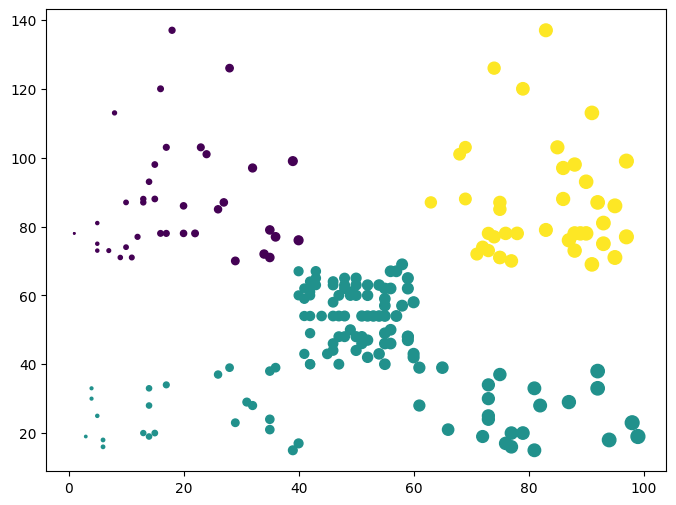

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(2, figsize=(8,6))
plt.clf()
ax = Axes3D(fig, rect =[0, 0, 1, 1], elev = 48, azim = 134)


plt.cla()
plt.scatter(X[:,1], X[:,0], X[:,1], c = labels.astype(np.float64), marker = 'o')
plt.show()